In [1]:
import json
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
RAW_PATH = Path("../data/raw/iowa_crash_data_raw.json")

with RAW_PATH.open("r", encoding="utf-8") as file:
    raw_data = json.load(file)

crashes = pd.DataFrame(
    feature["attributes"]
    for feature in raw_data["features"]
)

In [3]:
crashes.head()

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,8931903,2.015841e+09,1421539200000,1421568000000,52,JOHNSON,5.0,1,3
1,8931904,2.015844e+09,1422835200000,1422879480000,64,MARSHALL,5.0,2,4
2,8931905,2.015844e+09,1423094400000,1423157100000,64,MARSHALL,5.0,1,1
3,8931906,2.015844e+09,1422403200000,1422404160000,64,MARSHALL,5.0,2,1
4,8931907,2.015844e+09,1423008000000,1423035300000,28,DELAWARE,5.0,1,1


In [4]:
crashes["CRASH_DATE"] = (
    pd.to_datetime(crashes["CRASH_DATE"], unit="ms")
    .dt.date 
)


crashes["CRASH_DATETIME"] = pd.to_datetime(
    crashes["CRASH_DATETIME"],
    unit="ms"
)

In [5]:
crashes.head()

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,8931903,2.015841e+09,2015-01-18,2015-01-18 08:00:00,52,JOHNSON,5.0,1,3
1,8931904,2.015844e+09,2015-02-02,2015-02-02 12:18:00,64,MARSHALL,5.0,2,4
2,8931905,2.015844e+09,2015-02-05,2015-02-05 17:25:00,64,MARSHALL,5.0,1,1
3,8931906,2.015844e+09,2015-01-28,2015-01-28 00:16:00,64,MARSHALL,5.0,2,1
4,8931907,2.015844e+09,2015-02-04,2015-02-04 07:35:00,28,DELAWARE,5.0,1,1


In [6]:
crashes.describe()

,OBJECTID,CRASH_KEY,CRASH_DATETIME,COUNTY_NUMBER,CSEV,WEATHER,CSRFCND
count,6.296030e+05,6.296030e+05,629603,629603.000000,629602.000000,629603.000000,629603.000000
mean,1.991306e+07,1.862379e+10,2020-10-01 07:30:05.252000,58.260062,4.568972,10.999484,10.580755
min,8.931903e+06,2.015836e+09,2015-01-01 00:13:00,0.000000,1.000000,1.000000,1.000000
25%,1.963688e+07,2.017102e+10,2017-11-10 17:23:30,32.000000,4.000000,1.000000,1.000000
50%,1.979428e+07,2.020119e+10,2020-09-22 17:00:00,64.000000,5.000000,1.000000,1.000000
75%,1.995168e+07,2.023138e+10,2023-08-31 23:52:30,78.000000,5.000000,2.000000,2.000000
max,2.544227e+07,2.026156e+10,2026-08-27 15:46:00,99.000000,5.000000,99.000000,99.000000
std,3.960329e+06,5.130475e+09,NaN,27.329521,0.792146,25.008862,24.713771


In [7]:
crashes.shape

(629603, 9)

In [8]:
crashes.columns

Index(['OBJECTID', 'CRASH_KEY', 'CRASH_DATE', 'CRASH_DATETIME',
       'COUNTY_NUMBER', 'COUNTY_NAME', 'CSEV', 'WEATHER', 'CSRFCND'],
      dtype='str')

In [9]:
print("OBJECTID unique:", crashes["OBJECTID"].is_unique)
print("Duplicated OBJECTIDs:", crashes["OBJECTID"].duplicated().sum())

OBJECTID unique: True
Duplicated OBJECTIDs: 0


In [10]:
crashes["CRASH_DATE"] = (
    pd.to_datetime(crashes["CRASH_DATE"], unit="ms")
    .dt.date 
)


crashes["CRASH_DATETIME"] = pd.to_datetime(
    crashes["CRASH_DATETIME"],
    unit="ms"
)

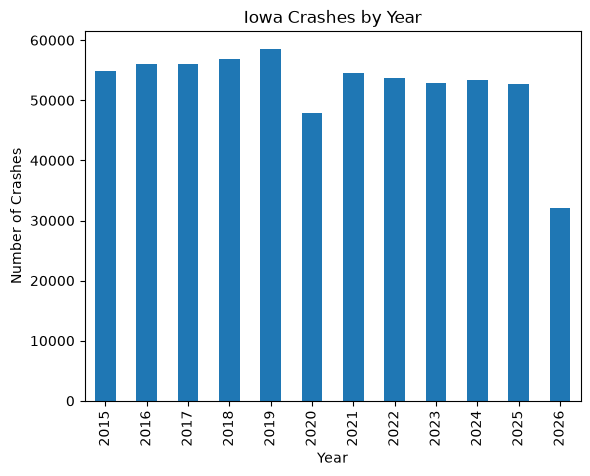

In [11]:
year_counts = (
    crashes["CRASH_DATE"]
    .apply(lambda date: date.year)
    .value_counts()
    .sort_index()
)


year_counts.plot(
    kind="bar",
    xlabel="Year",
    ylabel="Number of Crashes",
    title="Iowa Crashes by Year"
)

plt.show()

In [12]:
print(crashes.isna().sum())
print(
    (
        (crashes["COUNTY_NUMBER"] == 0)
        & crashes["COUNTY_NAME"].isna()
    ).sum()
)


OBJECTID             0
CRASH_KEY            0
CRASH_DATE           0
CRASH_DATETIME       0
COUNTY_NUMBER        0
COUNTY_NAME       1118
CSEV                 1
WEATHER              0
CSRFCND              0
dtype: int64
1118


In [13]:
crashes[crashes[["COUNTY_NUMBER"]] == 0]

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
629598,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
629599,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
629600,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
629601,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
